<a href="https://colab.research.google.com/github/Boni1995/DSE_thesis/blob/main/Intermediate_Survey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Libraries**

In [166]:
!pip install ydata-profiling

In [167]:
# Data Manipulation
import pandas as pd
import numpy as np

# Text Processing & NLP
import re
import unicodedata
import spacy
from sentence_transformers import SentenceTransformer, util
from sklearn.feature_extraction.text import TfidfVectorizer

# Data Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import networkx as nx

# Data Profiling
from ydata_profiling import ProfileReport

# **Import Data**

In [168]:
df = pd.read_excel(r'/content/drive/MyDrive/Colab Notebooks/DSE Thesis/3. Intermediate Surveys/2. Tourism surveyEncuesta de turismo(1-25)_TRANSLATED.xlsx')

In [169]:
# Change column names
df.columns = ["ID","bad_trip_story", "representative_trip", "vacation_story", "scene_1", "scene_2", "scene_3", "scene_4", "best_story_choice", "screen_choice", "decisive_info",
              "choose_method_steps", "choose_step_1", "choose_step_2", "choose_step_3", "advice_to_past_self", "advice_step_1", "advice_step_2", "advice_step_3",
              "destination_list_choice", "info_saturation", "missing_factor", "reference_map", "too_cheap_price", "bargain_price", "getting_expensive_price",
              "too_expensive_price", "trip_organizer", "main_travel_purpose", "trip_length_choice", "traveler_type", "first_info_source", "age_group", "gender", "residence",
              "occupation", "language", "trip_type"]

In [170]:
df.head(1)

,ID,bad_trip_story,representative_trip,vacation_story,scene_1,scene_2,scene_3,scene_4,best_story_choice,screen_choice,...,main_travel_purpose,trip_length_choice,traveler_type,first_info_source,age_group,gender,residence,occupation,language,trip_type
0,1,The destination was Curaçao. We chose it mostl...,The trip to Europe we took in 2024: we stayed ...,NaN,"Flight to Milan, stay in an apartment for 5 days","Train to Venice, stay in an apartment for 4 or...",Cruise through the Greek Islands and Istanbul,Return to Argentina,I check flexibility/free cancellation and deci...,B,...,See new cities or explore new destinations (Ve...,"Long, because once you pay for the ticket — wh...",Family traveler (Viajo en familia);Couple trav...,Social media (Redes sociales),35-59,Female (Femenino),South America (América del Sur),Self-employed (Independiente),SP,Long


# **Functions to use**

## Van Westendorp

In [171]:
# Function to calculate intersection points between two curves
def find_intersection(x1, y1, x2, y2):
    # Interpolate both curves onto a common x-axis grid
    common_x = np.linspace(max(min(x1), min(x2)), min(max(x1), max(x2)), 500)
    y1_interp = np.interp(common_x, x1, y1)
    y2_interp = np.interp(common_x, x2, y2)

    # Calculate the difference between the two curves
    diff = y1_interp - y2_interp
    sign_change = np.where(np.diff(np.sign(diff)))[0]  # Detect zero-crossing

    # Calculate intersections
    intersections = []
    for idx in sign_change:
        x_intersect = np.interp(0, [diff[idx], diff[idx + 1]], [common_x[idx], common_x[idx + 1]])
        y_intersect = np.interp(x_intersect, x1, y1)  # Use one curve for the y-value
        intersections.append((x_intersect, y_intersect))
    return intersections

# Van Westendorp analysis function (no product_name)
def van_westendorp_analysis(df):
    # Extract the relevant columns
    too_cheap = df['too_cheap']
    cheap = df['cheap']
    expensive = df['expensive']
    too_expensive = df['too_expensive']

    # Function to calculate cumulative percentages
    def calculate_cumulative_percent(series, invert=False):
        sorted_series = np.sort(series)
        cum_percent = np.arange(1, len(sorted_series) + 1) / len(sorted_series) * 100
        if invert:
            cum_percent = 100 - cum_percent
        return sorted_series, cum_percent

    # Calculate cumulative percentages
    too_cheap_sorted, too_cheap_cum = calculate_cumulative_percent(too_cheap, invert=True)
    cheap_sorted, cheap_cum = calculate_cumulative_percent(cheap, invert=True)
    expensive_sorted, expensive_cum = calculate_cumulative_percent(expensive)
    too_expensive_sorted, too_expensive_cum = calculate_cumulative_percent(too_expensive)

    # Find intersections
    marginal_cheapness = find_intersection(too_cheap_sorted, too_cheap_cum, expensive_sorted, expensive_cum)
    marginal_expensiveness = find_intersection(too_expensive_sorted, too_expensive_cum, cheap_sorted, cheap_cum)
    indifference_price_point = find_intersection(cheap_sorted, cheap_cum, expensive_sorted, expensive_cum)
    optimal_price_point = find_intersection(too_cheap_sorted, too_cheap_cum, too_expensive_sorted, too_expensive_cum)

    # Extract specific x-values for range of acceptable prices
    x_marginal_cheapness = marginal_cheapness[0][0] if marginal_cheapness else None
    x_marginal_expensiveness = marginal_expensiveness[0][0] if marginal_expensiveness else None

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.plot(too_cheap_sorted, too_cheap_cum, label='Too Cheap', color='orange')
    plt.plot(cheap_sorted, cheap_cum, label='Cheap', color='green')
    plt.plot(expensive_sorted, expensive_cum, label='Expensive', color='blue')
    plt.plot(too_expensive_sorted, too_expensive_cum, label='Too Expensive', color='red')

    # Mark intersection points with labels
    for x, y in marginal_cheapness:
        plt.scatter(x, y, color='purple', label=f'Point of Marginal Cheapness ({x:.2f})')
    for x, y in marginal_expensiveness:
        plt.scatter(x, y, color='brown', label=f'Point of Marginal Expensiveness ({x:.2f})')
    for x, y in indifference_price_point:
        plt.scatter(x, y, color='blue', label=f'Indifference Price Point ({x:.2f})')
    for x, y in optimal_price_point:
        plt.scatter(x, y, color='green', label=f'Optimal Price Point ({x:.2f})')

    # Draw vertical lines and label the range of acceptable prices
    if x_marginal_cheapness and x_marginal_expensiveness:
        plt.axvline(x=x_marginal_cheapness, color='purple', linestyle='--', label='Point of Marginal Cheapness')
        plt.axvline(x=x_marginal_expensiveness, color='brown', linestyle='--', label='Point of Marginal Expensiveness')
        plt.fill_betweenx([0, 100], x_marginal_cheapness, x_marginal_expensiveness, color='gray', alpha=0.3, label='Range of Acceptable Prices')

    plt.title("Van Westendorp Price Sensitivity Meter")
    plt.xlabel("Price")
    plt.ylabel("Cumulative Percentage (%)")
    plt.legend()
    plt.grid()
    plt.show()

    # Report only x-values
    print("Van Westendorp Analysis:")
    print(f"Point of Marginal Cheapness: {x_marginal_cheapness:.2f}" if x_marginal_cheapness else "Point of Marginal Cheapness: Not found")
    print(f"Point of Marginal Expensiveness: {x_marginal_expensiveness:.2f}" if x_marginal_expensiveness else "Point of Marginal Expensiveness: Not found")
    print(f"Indifference Price Point: {indifference_price_point[0][0]:.2f}" if indifference_price_point else "Indifference Price Point: Not found")
    print(f"Optimal Price Point: {optimal_price_point[0][0]:.2f}" if optimal_price_point else "Optimal Price Point: Not found")
    print("\n")

## Text Cleaning and Tokenization

In [172]:
def text_pipeline(df, input_col, stopwords="Yes"):
    processed_tokens = []

    for text in df[input_col]:
        if pd.isna(text):
            processed_tokens.append([])
            continue

        text = text.lower()

        text = re.sub(r"[^a-z0-9\s]", " ", text)

        doc = nlp(text)

        if stopwords.lower() == "yes":
            tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
        else:
            tokens = [token.lemma_ for token in doc if token.is_alpha]

        processed_tokens.append(tokens)

    df = df.copy()
    df["final_tokens"] = processed_tokens

    return df

## Text Cleaning for Embedding

In [173]:
def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove accents (´)
    text = ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

    # Remove strange characters
    text = re.sub(r'[^a-záéíóúñü\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# **EDA**

## Age Range

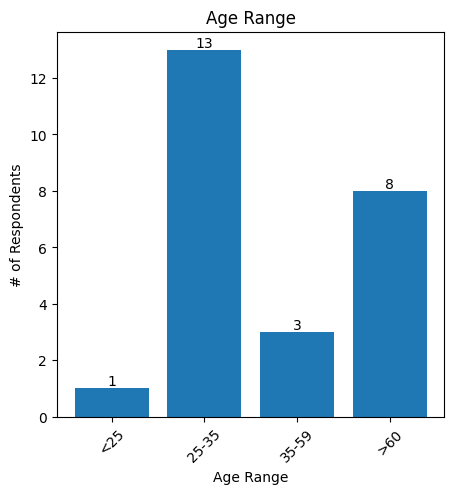

In [174]:
age_range = df["age_group"]
count = age_range.value_counts()
order = ["<25", "25-35", "35-59", ">60"]
count = count.reindex(order)

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

bars = ax.bar(count.index, count.values)

ax.bar_label(bars, labels=count.values)

plt.xlabel("Age Range")
plt.ylabel("# of Respondents")
plt.title("Age Range")
plt.xticks(rotation=45)
plt.show()

## Gender

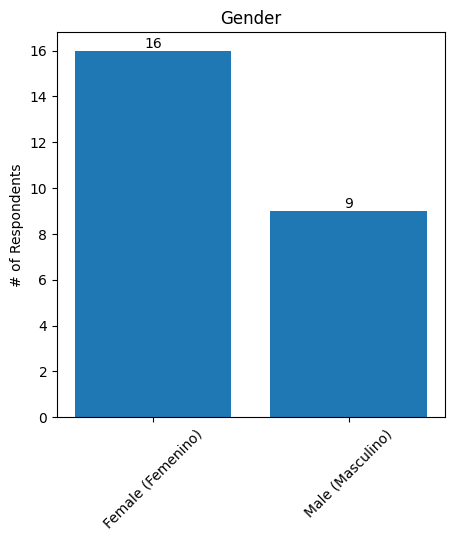

In [175]:
gender = df["gender"]
count = gender.value_counts()

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

bars = ax.bar(count.index, count.values)

ax.bar_label(bars, labels=count.values)

plt.ylabel("# of Respondents")
plt.title("Gender")
plt.xticks(rotation=45)
plt.show()

## Place of Residence

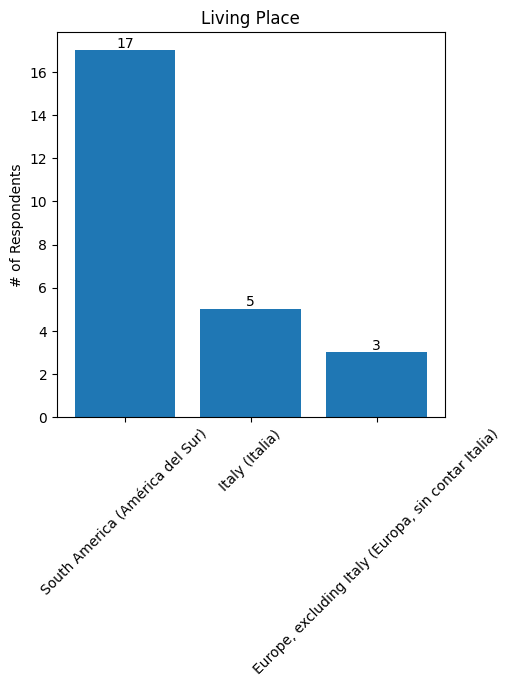

In [176]:
residence = df["residence"]
count = residence.value_counts()

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

bars = ax.bar(count.index, count.values)

ax.bar_label(bars, labels=count.values)

plt.ylabel("# of Respondents")
plt.title("Living Place")
plt.xticks(rotation=45)
plt.show()

## Occupation

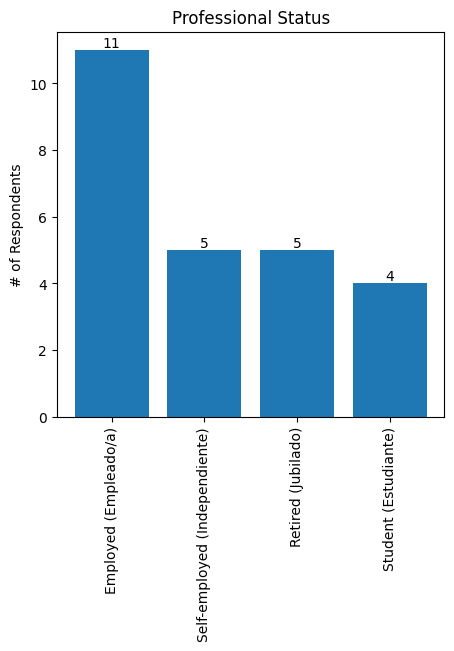

In [177]:
professional = df["occupation"]
count = professional.value_counts()

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

bars = ax.bar(count.index, count.values)

ax.bar_label(bars, labels=count.values)

plt.ylabel("# of Respondents")
plt.title("Professional Status")
plt.xticks(rotation=90)
plt.show()

## Trip Organization

/tmp/ipython-input-1479064225.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_by_age = df.groupby([age_range_cat, organizator]).size().unstack(fill_value=0)


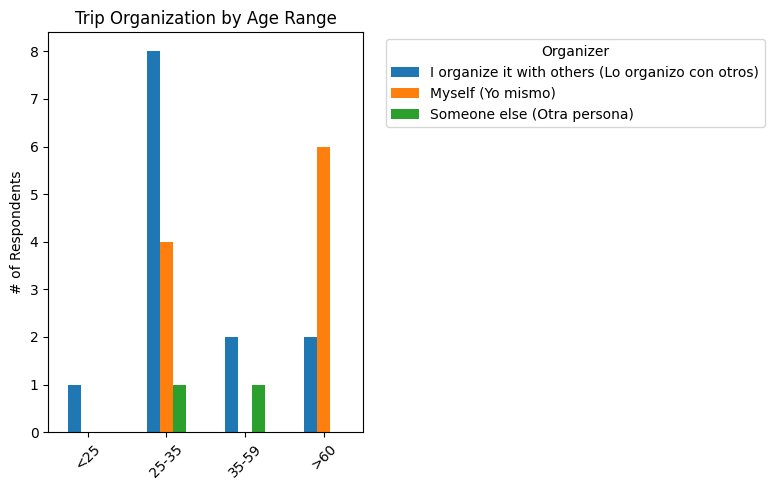

In [178]:
organizator = df["trip_organizer"]

age_range_cat = pd.Categorical(age_range, categories=order, ordered=True)

count_by_age = df.groupby([age_range_cat, organizator]).size().unstack(fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

bars = count_by_age.plot(kind="bar", ax=ax)

ax.set_xlabel("")
plt.ylabel("# of Respondents")
plt.title("Trip Organization by Age Range")
plt.xticks(rotation=45)
plt.legend(title="Organizer", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Travel Purpose

/tmp/ipython-input-3929348234.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_by_age = temp_df.groupby(["AgeRange", "Purpose"]).size().unstack(fill_value=0)


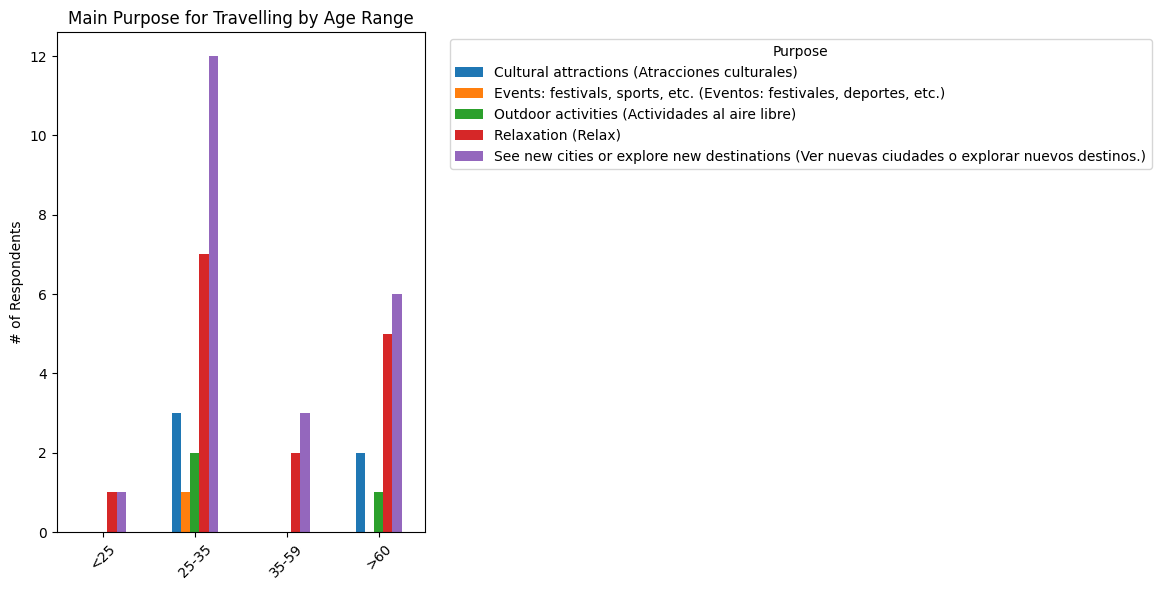

In [179]:
purpose = df["main_travel_purpose"]

age_range_cat = pd.Categorical(age_range, categories=order, ordered=True)

temp_df = pd.DataFrame({"Purpose": purpose, "AgeRange": age_range_cat})

temp_df = temp_df.assign(Purpose=temp_df["Purpose"].str.split(";")).explode("Purpose")

temp_df["Purpose"] = temp_df["Purpose"].str.strip()
temp_df = temp_df[temp_df["Purpose"].notna() & (temp_df["Purpose"] != "")]

count_by_age = temp_df.groupby(["AgeRange", "Purpose"]).size().unstack(fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
count_by_age.plot(kind="bar", ax=ax)

ax.set_xlabel("")
plt.ylabel("# of Respondents")
plt.title("Main Purpose for Travelling by Age Range")
plt.xticks(rotation=45)
plt.legend(title="Purpose", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Travel Type

/tmp/ipython-input-1174850393.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_by_age = temp_df.groupby(["AgeRange", "Traveler"]).size().unstack(fill_value=0)


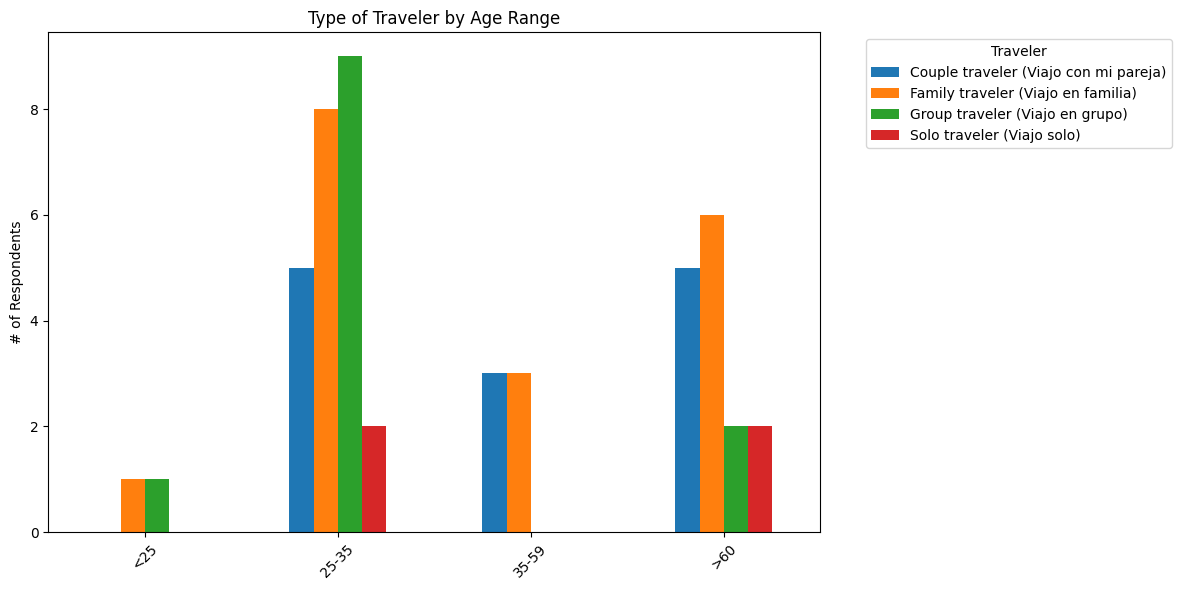

In [180]:
traveler = df["traveler_type"]

age_range_cat = pd.Categorical(age_range, categories=order, ordered=True)

temp_df = pd.DataFrame({"Traveler": traveler, "AgeRange": age_range_cat})

temp_df = temp_df.assign(Traveler=temp_df["Traveler"].str.split(";")).explode("Traveler")

temp_df["Traveler"] = temp_df["Traveler"].str.strip()
temp_df = temp_df[temp_df["Traveler"].notna() & (temp_df["Traveler"] != "")]

count_by_age = temp_df.groupby(["AgeRange", "Traveler"]).size().unstack(fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
count_by_age.plot(kind="bar", ax=ax)

ax.set_xlabel("")
plt.ylabel("# of Respondents")
plt.title("Type of Traveler by Age Range")
plt.xticks(rotation=45)
plt.legend(title="Traveler", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Source of Information

/tmp/ipython-input-2849387788.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_by_age = temp_df.groupby(["AgeRange", "TravelInfo"]).size().unstack(fill_value=0)


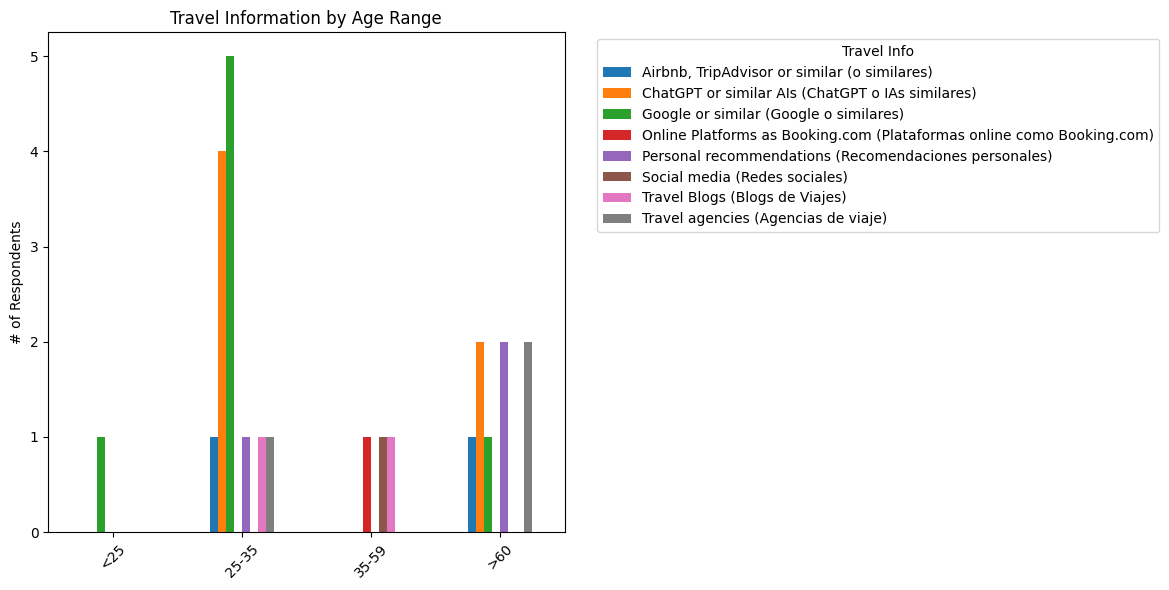

In [181]:
travel_info = df["first_info_source"]

age_range_cat = pd.Categorical(age_range, categories=order, ordered=True)

temp_df = pd.DataFrame({"TravelInfo": travel_info, "AgeRange": age_range_cat})

temp_df["TravelInfo"] = temp_df["TravelInfo"].astype(str).str.strip()
temp_df = temp_df[temp_df["TravelInfo"].notna() & (temp_df["TravelInfo"] != "")]

count_by_age = temp_df.groupby(["AgeRange", "TravelInfo"]).size().unstack(fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
count_by_age.plot(kind="bar", ax=ax)

ax.set_xlabel("")  # Quita el título del eje X
plt.ylabel("# of Respondents")
plt.title("Travel Information by Age Range")
plt.xticks(rotation=45)
plt.legend(title="Travel Info", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Best Story

/tmp/ipython-input-2999569928.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_by_age = temp_df.groupby(["AgeRange", "Story"]).size().unstack(fill_value=0)
/tmp/ipython-input-2999569928.py:21: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


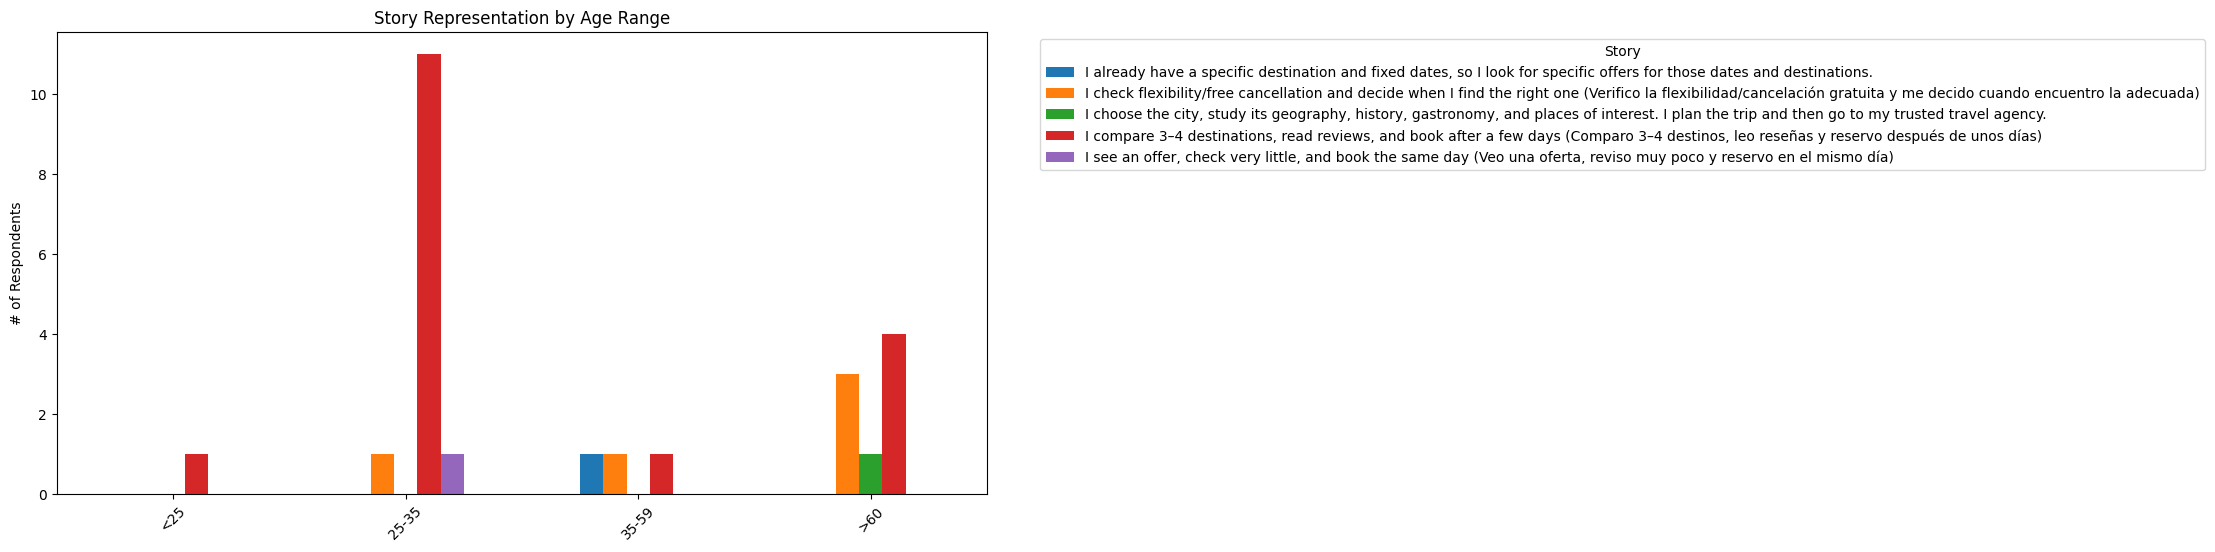

In [182]:
story = df["best_story_choice"]

age_range_cat = pd.Categorical(age_range, categories=order, ordered=True)

temp_df = pd.DataFrame({"Story": story, "AgeRange": age_range_cat})

temp_df["Story"] = temp_df["Story"].astype(str).str.strip()
temp_df = temp_df[temp_df["Story"].notna() & (temp_df["Story"] != "")]

count_by_age = temp_df.groupby(["AgeRange", "Story"]).size().unstack(fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
count_by_age.plot(kind="bar", ax=ax)

ax.set_xlabel("")  # Quita el título del eje X
plt.ylabel("# of Respondents")
plt.title("Story Representation by Age Range")
plt.xticks(rotation=45)
plt.legend(title="Story", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# EDA Conclusion
According to descriptive answers, the average respondent is:
- Between 25-25 years old, but also described with a second group >60.
- Mostly female.
- Employed.
- Mostly from South America.
- Tends to organize with others the trips, and travels with more people (can be the partner, family or friends).
- Usually travels to explore new cities, although some relaxation is needed.
- Younger people tend to use Google or similar, and in some cases ChatGPT, while older people also tend to use travel blogs or agencies.
- Tends to take some time to analyze 3 or 4 options, and after some days books.

# **Van Westendorp**

## All Data

### Data Preparation

In [183]:
df_vw = df.iloc[:, 23:27]

In [184]:
df_vw.columns = ['too_cheap', 'cheap', 'expensive', 'too_expensive']

In [185]:
df_vw = df_vw[
    (df_vw['too_cheap'] <= df_vw['cheap']) &
    (df_vw['cheap'] <= df_vw['expensive']) &
    (df_vw['expensive'] <= df_vw['too_expensive'])
]

In [186]:
df_vw

,too_cheap,cheap,expensive,too_expensive
0,200,250,500,800
1,80,120,200,250
2,100,150,200,250
3,80,140,160,190
4,60,150,250,450
5,100,200,300,400
6,90,120,135,160
7,200,600,1300,2500
8,150,200,400,600
9,31,37,40,50


In [187]:
# Inter Quartile Range
Q1 = df_vw.quantile(0.25)
Q3 = df_vw.quantile(0.75)
IQR = Q3 - Q1

# Filtering
mask = ~(
    (df_vw < (Q1 - 1.5 * IQR)) |
    (df_vw > (Q3 + 1.5 * IQR))
).any(axis=1)

# New dataset
df_vw_clean = df_vw[mask]

In [188]:
df_vw_clean

,too_cheap,cheap,expensive,too_expensive
0,200,250,500,800
1,80,120,200,250
2,100,150,200,250
3,80,140,160,190
4,60,150,250,450
5,100,200,300,400
6,90,120,135,160
8,150,200,400,600
10,100,150,250,400
11,50,100,300,600


### With Outliers

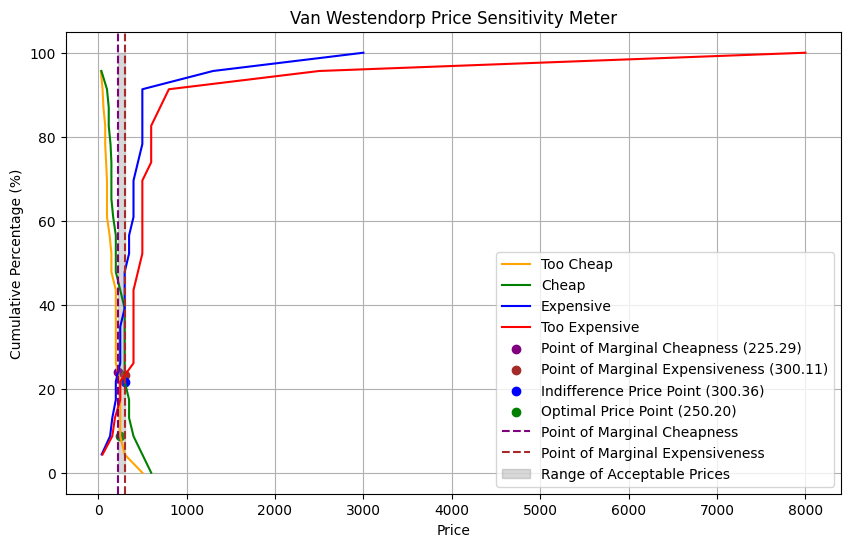

Van Westendorp Analysis:
Point of Marginal Cheapness: 225.29
Point of Marginal Expensiveness: 300.11
Indifference Price Point: 300.36
Optimal Price Point: 250.20




In [189]:
van_westendorp_analysis(df_vw)

### Without Outliers

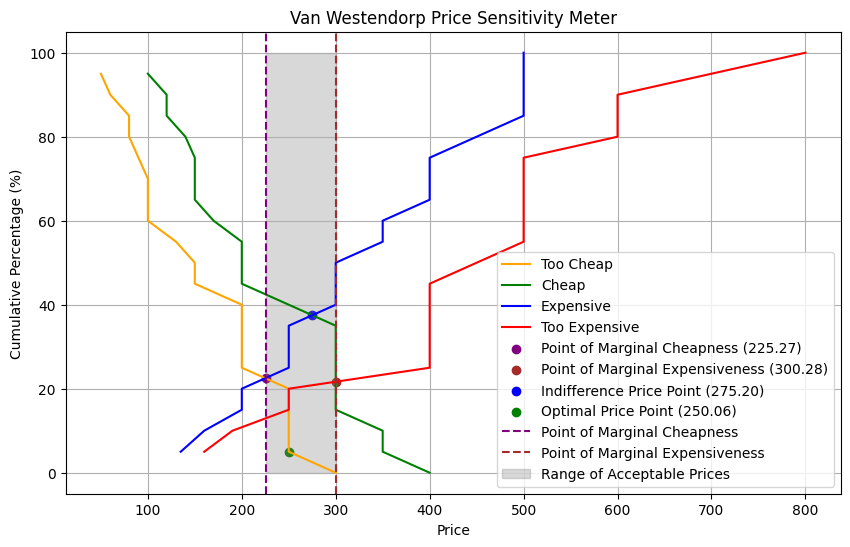

Van Westendorp Analysis:
Point of Marginal Cheapness: 225.27
Point of Marginal Expensiveness: 300.28
Indifference Price Point: 275.20
Optimal Price Point: 250.06




In [190]:
van_westendorp_analysis(df_vw_clean)

## Young (<25 & 25-35)

In [191]:
df_young = df.loc[age_range.isin(["<25", "25-35"]), df.columns[23:27]]
df_young.columns = ['too_cheap', 'cheap', 'expensive', 'too_expensive']

# Remove illogical cases
df_young = df_young[
    (df_young['too_cheap'] <= df_young['cheap']) &
    (df_young['cheap'] <= df_young['expensive']) &
    (df_young['expensive'] <= df_young['too_expensive'])
]

#Remove outliers
# Inter Quartile Range
Q1 = df_young.quantile(0.25)
Q3 = df_young.quantile(0.75)
IQR = Q3 - Q1

# Filtering
mask = ~(
    (df_young < (Q1 - 1.5 * IQR)) |
    (df_young > (Q3 + 1.5 * IQR))
).any(axis=1)

# New dataset
df_young = df_young[mask]


df_young

,too_cheap,cheap,expensive,too_expensive
1,80,120,200,250
2,100,150,200,250
4,60,150,250,450
5,100,200,300,400
6,90,120,135,160
8,150,200,400,600
9,31,37,40,50
10,100,150,250,400
11,50,100,300,600
13,250,300,400,500


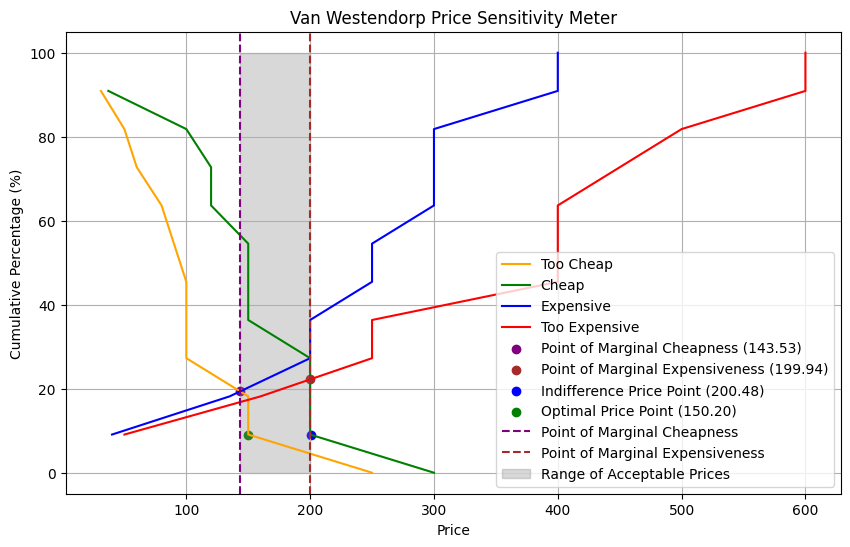

Van Westendorp Analysis:
Point of Marginal Cheapness: 143.53
Point of Marginal Expensiveness: 199.94
Indifference Price Point: 200.48
Optimal Price Point: 150.20




In [192]:
van_westendorp_analysis(df_young)

## Older (>35)

Excluding the outliers won't retrieve an OPP, so they were kept for calculation

In [193]:
df_old = df.loc[age_range.isin(["35-59", ">60"]), df.columns[23:27]]
df_old.columns = ['too_cheap', 'cheap', 'expensive', 'too_expensive']

# Remove illogical cases
df_old = df_old[
    (df_old['too_cheap'] <= df_old['cheap']) &
    (df_old['cheap'] <= df_old['expensive']) &
    (df_old['expensive'] <= df_old['too_expensive'])
]

df_old

,too_cheap,cheap,expensive,too_expensive
0,200,250,500,800
3,80,140,160,190
15,250,300,500,700
16,200,300,350,500
19,130,170,250,400
20,200,400,500,500
21,300,350,450,500
22,200,300,350,400
23,500,500,3000,8000
24,250,300,400,500


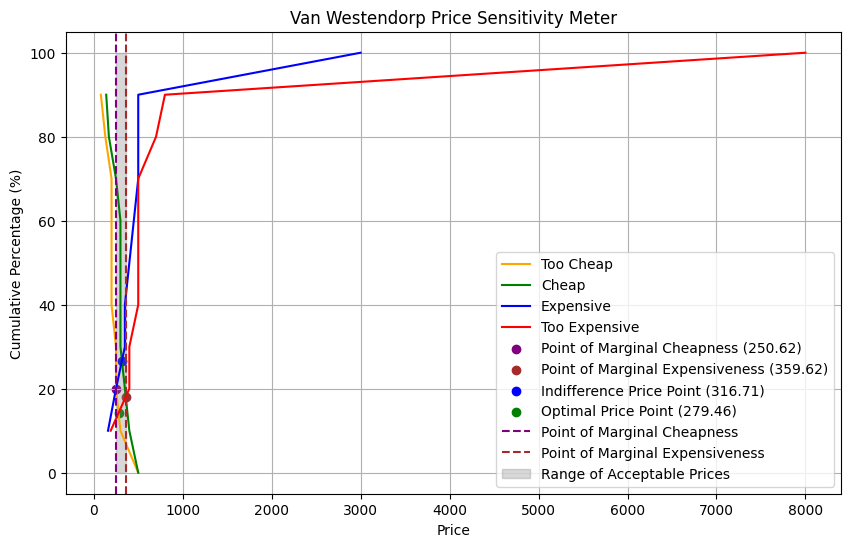

Van Westendorp Analysis:
Point of Marginal Cheapness: 250.62
Point of Marginal Expensiveness: 359.62
Indifference Price Point: 316.71
Optimal Price Point: 279.46




In [194]:
van_westendorp_analysis(df_old)

In [195]:
#Remove outliers

#Inter Quartile Range
Q1 = df_old.quantile(0.25)
Q3 = df_old.quantile(0.75)
IQR = Q3 - Q1

# Filtering
mask = ~(
    (df_old < (Q1 - 1.5 * IQR)) |
    (df_old > (Q3 + 1.5 * IQR))
).any(axis=1)

# New dataset
df_old = df_old[mask]

df_old

,too_cheap,cheap,expensive,too_expensive
0,200,250,500,800
15,250,300,500,700
16,200,300,350,500
19,130,170,250,400
20,200,400,500,500
21,300,350,450,500
22,200,300,350,400
24,250,300,400,500


In [196]:
df_old.median()

,0
too_cheap,200.0
cheap,300.0
expensive,425.0
too_expensive,500.0


# Van Westendorp Result
When analyzing the full sample (after removing outliers and illogical responses), the **Optimal Price Point (OPP) is found at €250.06**.

When segmenting the analysis to include only **respondents aged 35 or younger**, the **OPP drops significantly to €150.20**.

On the other hand, **respondents older than 35 years old** have an **OPP (including outliers) of €279.46**.

This indicates that younger respondents show **greater price sensitivity**, being willing to pay considerably less than older respondents, who generally display a higher willingness to pay.

# **Screen Analysis**

## Screen Choice

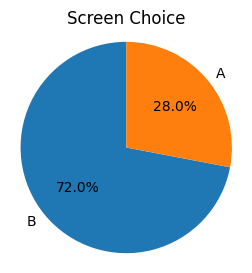

In [197]:
counts = df['screen_choice'].value_counts()

plt.figure(figsize=(3, 3))
plt.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90)
plt.title(f"Screen Choice")
plt.axis("equal")
plt.show()


## Whole DF

In [198]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

In [199]:
df_screen_schoice = df[['screen_choice', 'decisive_info']]

In [200]:
screen_choice = text_pipeline(df_screen_schoice, input_col = 'decisive_info')

In [201]:
# Tokens to strings
docs = [" ".join(tokens) for tokens in screen_choice["final_tokens"]]

# TF-IDF for single words
vectorizer_words = TfidfVectorizer(ngram_range=(1, 1))
X_words = vectorizer_words.fit_transform(docs)

# Average TF-IDF
tfidf_means_words = X_words.mean(axis=0).A1
words = vectorizer_words.get_feature_names_out()

# Order by Importance
top_words_idx = tfidf_means_words.argsort()[::-1]
top_words = pd.DataFrame({
    "word": words[top_words_idx],
    "tfidf": tfidf_means_words[top_words_idx]
}).head(20)

# TF-IDF for bigrams
vectorizer_bigrams = TfidfVectorizer(ngram_range=(2, 2))
X_bigrams = vectorizer_bigrams.fit_transform(docs)

tfidf_means_bigrams = X_bigrams.mean(axis=0).A1
bigrams = vectorizer_bigrams.get_feature_names_out()

top_bigrams_idx = tfidf_means_bigrams.argsort()[::-1]
top_bigrams = pd.DataFrame({
    "bigram": bigrams[top_bigrams_idx],
    "tfidf": tfidf_means_bigrams[top_bigrams_idx]
}).head(20)

## Whole DF Results

In [202]:
print(top_words)

            word     tfidf
0   cancellation  0.272345
1           free  0.268024
2         review  0.192402
3          price  0.154340
4         number  0.075532
5         rating  0.068724
6           good  0.060945
7           base  0.046603
8           well  0.034421
9            yes  0.034266
10        choose  0.025278
11        option  0.023355
12          like  0.022940
13          sure  0.021813
14          help  0.021813
15        decide  0.021813
16    reassuring  0.017273
17         thing  0.017273
18          mind  0.017273
19        change  0.017273


In [203]:
print(top_bigrams)

                     bigram     tfidf
0         free cancellation  0.348628
1             number review  0.089451
2              price review  0.080000
3               good rating  0.050457
4               base review  0.040000
5          cancellation yes  0.036683
6               rating free  0.028466
7         cancellation good  0.028466
8               well rating  0.024007
9         cancellation help  0.022399
10              help decide  0.022399
11                sure free  0.022399
12         reassuring thing  0.017560
13  cancellation reassuring  0.017560
14             thing change  0.017560
15              mind cancel  0.017560
16              change mind  0.017560
17    important combination  0.015356
18         combination free  0.015356
19         cancelation well  0.015356


## Choice A

In [204]:
df_screen_schoice = df[df['screen_choice'] == "A"][['screen_choice', 'decisive_info']]

In [205]:
screen_choice = text_pipeline(df_screen_schoice, input_col = 'decisive_info')

In [206]:
# Tokens to strings
docs = [" ".join(tokens) for tokens in screen_choice["final_tokens"]]

# TF-IDF for single words
vectorizer_words = TfidfVectorizer(ngram_range=(1, 1))
X_words = vectorizer_words.fit_transform(docs)

# Average TF-IDF
tfidf_means_words = X_words.mean(axis=0).A1
words = vectorizer_words.get_feature_names_out()

# Order by Importance
top_words_idx = tfidf_means_words.argsort()[::-1]
top_words = pd.DataFrame({
    "word": words[top_words_idx],
    "tfidf": tfidf_means_words[top_words_idx]
}).head(20)

# TF-IDF for bigrams
vectorizer_bigrams = TfidfVectorizer(ngram_range=(2, 2))
X_bigrams = vectorizer_bigrams.fit_transform(docs)

tfidf_means_bigrams = X_bigrams.mean(axis=0).A1
bigrams = vectorizer_bigrams.get_feature_names_out()

top_bigrams_idx = tfidf_means_bigrams.argsort()[::-1]
top_bigrams = pd.DataFrame({
    "bigram": bigrams[top_bigrams_idx],
    "tfidf": tfidf_means_bigrams[top_bigrams_idx]
}).head(20)

## Choice A Results

In [207]:
print(top_words)

          word     tfidf
0        price  0.500633
1       review  0.347974
2       number  0.125721
3         base  0.125721
4        short  0.044532
5         trip  0.044532
6     quantity  0.044532
7   relatively  0.044532
8        round  0.044532
9   particular  0.044532
10       level  0.044532
11    consider  0.044532
12  commitment  0.044532
13      assume  0.044532


In [208]:
print(top_bigrams)

                   bigram     tfidf
0            price review  0.285714
1           number review  0.142857
2             base review  0.142857
3        short particular  0.045175
4         trip relatively  0.045175
5         quantity review  0.045175
6        relatively short  0.045175
7              round trip  0.045175
8   particular commitment  0.045175
9          level quantity  0.045175
10         consider level  0.045175
11    commitment consider  0.045175
12           assume round  0.045175


## Choice B

In [209]:
df_screen_schoice = df[df['screen_choice'] == "B"][['screen_choice', 'decisive_info']]

In [210]:
screen_choice = text_pipeline(df_screen_schoice, input_col = 'decisive_info')

In [211]:
# Tokens to strings
docs = [" ".join(tokens) for tokens in screen_choice["final_tokens"]]

# TF-IDF for single words
vectorizer_words = TfidfVectorizer(ngram_range=(1, 1))
X_words = vectorizer_words.fit_transform(docs)

# Average TF-IDF
tfidf_means_words = X_words.mean(axis=0).A1
words = vectorizer_words.get_feature_names_out()

# Order by Importance
top_words_idx = tfidf_means_words.argsort()[::-1]
top_words = pd.DataFrame({
    "word": words[top_words_idx],
    "tfidf": tfidf_means_words[top_words_idx]
}).head(20)

# TF-IDF for bigrams
vectorizer_bigrams = TfidfVectorizer(ngram_range=(2, 2))
X_bigrams = vectorizer_bigrams.fit_transform(docs)

tfidf_means_bigrams = X_bigrams.mean(axis=0).A1
bigrams = vectorizer_bigrams.get_feature_names_out()

top_bigrams_idx = tfidf_means_bigrams.argsort()[::-1]
top_bigrams = pd.DataFrame({
    "bigram": bigrams[top_bigrams_idx],
    "tfidf": tfidf_means_bigrams[top_bigrams_idx]
}).head(20)

## Choice B Results

In [212]:
print(top_words)

            word     tfidf
0   cancellation  0.370163
1           free  0.358994
2         review  0.140189
3         rating  0.095058
4           good  0.086342
5         number  0.057079
6            yes  0.049210
7           well  0.044306
8         choose  0.033932
9         option  0.032287
10        decide  0.030701
11          help  0.030701
12          sure  0.030701
13          like  0.029487
14        change  0.024190
15         thing  0.024190
16    reassuring  0.024190
17          mind  0.024190
18        cancel  0.024190
19     important  0.022622


In [213]:
print(top_bigrams)

                     bigram     tfidf
0         free cancellation  0.473246
1               good rating  0.070357
2             number review  0.069786
3          cancellation yes  0.051928
4         cancellation good  0.040191
5               rating free  0.040191
6               well rating  0.032925
7         cancellation help  0.031329
8                 sure free  0.031329
9               help decide  0.031329
10              mind cancel  0.024494
11         reassuring thing  0.024494
12             thing change  0.024494
13  cancellation reassuring  0.024494
14              change mind  0.024494
15          price important  0.021358
16            rating choose  0.021358
17         free cancelation  0.021358
18    important combination  0.021358
19         cancelation well  0.021358


# Screen Choice Main Results

In general, people prefered **option B**, mainly explained by the **free cancellation**. Some cases also considered important the **reviews**, but in a second place.

On the other hand, those who choose **option A** highlighted mainly the **price** as main reason for their choice.

# **Type of Trip**

## Count by Type

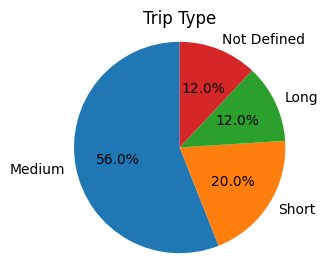

In [214]:
counts = df['trip_type'].value_counts()

plt.figure(figsize=(3, 3))
plt.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90)
plt.title(f"Trip Type")
plt.axis("equal")
plt.show()

## TF/IDF Preparation

In [215]:
type_trip = df.iloc[:,[0,29,37]]

In [216]:
df_type_trip = text_pipeline(type_trip, input_col = 'trip_length_choice')

## Long Trip

In [217]:
long_trip = df_type_trip[df_type_trip['trip_type'] == 'Long']
long_trip = long_trip[['trip_type', 'final_tokens']]

In [218]:
# Remove redundant words
redundant = {"long", "trip", "length"}

filtered_docs = [
    " ".join([tok for tok in tokens if tok.lower() not in redundant and tok.isalpha()])
    for tokens in long_trip["final_tokens"]
]

# TF-IDF for single words
vectorizer_words = TfidfVectorizer(ngram_range=(1, 1))
X_words = vectorizer_words.fit_transform(filtered_docs)

# Average TF-IDF
tfidf_means_words = X_words.mean(axis=0).A1
words = vectorizer_words.get_feature_names_out()

# Order by Importance
top_words_idx = tfidf_means_words.argsort()[::-1]
top_words = pd.DataFrame({
    "word": words[top_words_idx],
    "tfidf": tfidf_means_words[top_words_idx]
}).head(20)

# TF-IDF for bigrams
vectorizer_bigrams = TfidfVectorizer(ngram_range=(2, 2))
X_bigrams = vectorizer_bigrams.fit_transform(filtered_docs)

tfidf_means_bigrams = X_bigrams.mean(axis=0).A1
bigrams = vectorizer_bigrams.get_feature_names_out()

top_bigrams_idx = tfidf_means_bigrams.argsort()[::-1]
top_bigrams = pd.DataFrame({
    "bigram": bigrams[top_bigrams_idx],
    "tfidf": tfidf_means_bigrams[top_bigrams_idx]
}).head(20)

# TF-IDF for trigrams
vectorizer_trigrams = TfidfVectorizer(ngram_range=(3, 3))
X_trigrams = vectorizer_trigrams.fit_transform(filtered_docs)

tfidf_means_trigrams = X_trigrams.mean(axis=0).A1
trigrams = vectorizer_trigrams.get_feature_names_out()

top_trigrams_idx = tfidf_means_trigrams.argsort()[::-1]
top_trigrams = pd.DataFrame({
    "bigram": trigrams[top_trigrams_idx],
    "tfidf": tfidf_means_trigrams[top_trigrams_idx]
}).head(20)

## Long Trip Results

In [219]:
top_words

,word,tfidf
0,way,0.235702
1,enjoy,0.235702
2,place,0.204336
3,visit,0.204336
4,ticket,0.134339
5,well,0.134339
6,pay,0.134339
7,mainly,0.134339
8,know,0.134339
9,expensive,0.134339


In [220]:
top_bigrams

,bigram,tfidf
0,way enjoy,0.333333
1,visit place,0.214668
2,well mainly,0.141131
3,ticket expensive,0.141131
4,place know,0.141131
5,pay ticket,0.141131
6,mainly disconnect,0.141131
7,know well,0.141131
8,expensive argentinians,0.141131
9,argentinians advantage,0.141131


In [221]:
top_trigrams

,bigram,tfidf
0,well mainly disconnect,0.149071
1,visit place know,0.149071
2,ticket expensive argentinians,0.149071
3,place know well,0.149071
4,pay ticket expensive,0.149071
5,know well mainly,0.149071
6,expensive argentinians advantage,0.149071
7,argentinians advantage visit,0.149071
8,advantage visit place,0.149071
9,able visit place,0.149071


## Medium

In [222]:
medium_trip = df_type_trip[df_type_trip['trip_type'] == 'Medium']
medium_trip = medium_trip[['trip_type', 'final_tokens']]

In [223]:
# Remove redundant words
redundant = {"medium", "trip", "length"}

filtered_docs = [
    " ".join([tok for tok in tokens if tok.lower() not in redundant and tok.isalpha()])
    for tokens in medium_trip["final_tokens"]
]

# TF-IDF for single words
vectorizer_words = TfidfVectorizer(ngram_range=(1, 1))
X_words = vectorizer_words.fit_transform(filtered_docs)

# Average TF-IDF
tfidf_means_words = X_words.mean(axis=0).A1
words = vectorizer_words.get_feature_names_out()

# Order by Importance
top_words_idx = tfidf_means_words.argsort()[::-1]
top_words = pd.DataFrame({
    "word": words[top_words_idx],
    "tfidf": tfidf_means_words[top_words_idx]
}).head(20)

# TF-IDF for bigrams
vectorizer_bigrams = TfidfVectorizer(ngram_range=(2, 2))
X_bigrams = vectorizer_bigrams.fit_transform(filtered_docs)

tfidf_means_bigrams = X_bigrams.mean(axis=0).A1
bigrams = vectorizer_bigrams.get_feature_names_out()

top_bigrams_idx = tfidf_means_bigrams.argsort()[::-1]
top_bigrams = pd.DataFrame({
    "bigram": bigrams[top_bigrams_idx],
    "tfidf": tfidf_means_bigrams[top_bigrams_idx]
}).head(20)

# TF-IDF for trigrams
vectorizer_trigrams = TfidfVectorizer(ngram_range=(3, 3))
X_trigrams = vectorizer_trigrams.fit_transform(filtered_docs)

tfidf_means_trigrams = X_trigrams.mean(axis=0).A1
trigrams = vectorizer_trigrams.get_feature_names_out()

top_trigrams_idx = tfidf_means_trigrams.argsort()[::-1]
top_trigrams = pd.DataFrame({
    "bigram": trigrams[top_trigrams_idx],
    "tfidf": tfidf_means_trigrams[top_trigrams_idx]
}).head(20)

## Medium Trip Results

In [224]:
top_words

,word,tfidf
0,time,0.097696
1,day,0.083468
2,generally,0.071429
3,short,0.067932
4,routine,0.065247
5,want,0.065247
6,daily,0.065247
7,think,0.063336
8,feel,0.060478
9,place,0.060302


In [225]:
top_bigrams

,bigram,tfidf
0,work issue,0.071429
1,daily routine,0.065655
2,think right,0.050508
3,right time,0.050508
4,day want,0.043080
5,want daily,0.043080
6,place distance,0.035714
7,distance country,0.035714
8,country origin,0.035714
9,depend place,0.035714


In [226]:
top_trigrams

,bigram,tfidf
0,think right time,0.071429
1,day want daily,0.050508
2,want daily routine,0.050508
3,place distance country,0.041239
4,distance country origin,0.041239
5,depend place distance,0.041239
6,shorter feel insufficient,0.035714
7,need return daily,0.035714
8,short make rush,0.035714
9,day feel need,0.035714


## Short

In [227]:
short_trip = df_type_trip[df_type_trip['trip_type'] == 'Short']
short_trip = short_trip[['trip_type', 'final_tokens']]

In [228]:
# Remove redundant words
redundant = {"short", "trip", "length"}

filtered_docs = [
    " ".join([tok for tok in tokens if tok.lower() not in redundant and tok.isalpha()])
    for tokens in short_trip["final_tokens"]
]

# TF-IDF for single words
vectorizer_words = TfidfVectorizer(ngram_range=(1, 1))
X_words = vectorizer_words.fit_transform(filtered_docs)

# Average TF-IDF
tfidf_means_words = X_words.mean(axis=0).A1
words = vectorizer_words.get_feature_names_out()

# Order by Importance
top_words_idx = tfidf_means_words.argsort()[::-1]
top_words = pd.DataFrame({
    "word": words[top_words_idx],
    "tfidf": tfidf_means_words[top_words_idx]
}).head(20)

# TF-IDF for bigrams
vectorizer_bigrams = TfidfVectorizer(ngram_range=(2, 2))
X_bigrams = vectorizer_bigrams.fit_transform(filtered_docs)

tfidf_means_bigrams = X_bigrams.mean(axis=0).A1
bigrams = vectorizer_bigrams.get_feature_names_out()

top_bigrams_idx = tfidf_means_bigrams.argsort()[::-1]
top_bigrams = pd.DataFrame({
    "bigram": bigrams[top_bigrams_idx],
    "tfidf": tfidf_means_bigrams[top_bigrams_idx]
}).head(20)

# TF-IDF for trigrams
vectorizer_trigrams = TfidfVectorizer(ngram_range=(3, 3))
X_trigrams = vectorizer_trigrams.fit_transform(filtered_docs)

tfidf_means_trigrams = X_trigrams.mean(axis=0).A1
trigrams = vectorizer_trigrams.get_feature_names_out()

top_trigrams_idx = tfidf_means_trigrams.argsort()[::-1]
top_trigrams = pd.DataFrame({
    "bigram": trigrams[top_trigrams_idx],
    "tfidf": tfidf_means_trigrams[top_trigrams_idx]
}).head(20)

## Short Trip Results

In [229]:
top_words

,word,tfidf
0,usually,0.110801
1,budget,0.100364
2,discover,0.094981
3,stay,0.092739
4,place,0.092739
5,night,0.092739
6,expensive,0.092739
7,choose,0.085257
8,planning,0.075593
9,hybrid,0.075593


In [230]:
top_bigrams

,bigram,tfidf
0,stay night,0.100000
1,night expensive,0.100000
2,place stay,0.100000
3,budget place,0.100000
4,usually choose,0.091713
5,require planning,0.081650
6,time hybrid,0.081650
7,hybrid job,0.081650
8,planning feasible,0.081650
9,feasible time,0.081650


In [231]:
top_trigrams

,bigram,tfidf
0,stay night expensive,0.115470
1,place stay night,0.115470
2,budget place stay,0.115470
3,time hybrid job,0.089443
4,require planning feasible,0.089443
5,planning feasible time,0.089443
6,cheap require planning,0.089443
7,feasible time hybrid,0.089443
8,plan day commitment,0.081650
9,medium affordable easy,0.081650


# Trip Type Results

Most respondents prefer **medium length trips**, followed by **short ones**. The main reason is that they feel it is the right lenght to **discover a new city** during their vacations. *Too short may not allow them to fully visit the city or to be in a rush, while too long may loose foucs of the trip*.

Also this shorter length trips (medium and short) are chosen over long trips as they require **less time off** from their jobs, and **less resources (mainly night stay price and budget)**.

Those who didn't define a specific length, mainly highlighted that they decide depending on **the location of the destination** (near, then a short trip, while travelling to another continent may require longer trips). Also, they suggested that **shorter trips are needed for some relaxation**.

# **Worst Trip - Data Preparation**

In [232]:
bad_trip_story = df.iloc[:, [0, 1, 32, 33, 34, 35]]

In [233]:
bad_trip_story["worst_trip_clean"] = bad_trip_story["bad_trip_story"].apply(clean_text)

/tmp/ipython-input-845671720.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bad_trip_story["worst_trip_clean"] = bad_trip_story["bad_trip_story"].apply(clean_text)


In [234]:
model = SentenceTransformer("all-mpnet-base-v2") # Simpler model is all-MiniLM-L6-v2
embeddings = model.encode(bad_trip_story["worst_trip_clean"], show_progress_bar=True)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [235]:
# Matrix between each respondent
cosine_matrix = util.cos_sim(embeddings, embeddings)

In [236]:
threshold = 0.7
similar_pairs = []

# Recorremos solo la parte superior de la matriz (para evitar duplicados y la diagonal)
for i in range(len(cosine_matrix)):
    for j in range(i+1, len(cosine_matrix)):
        sim = cosine_matrix[i, j]
        if sim > threshold:
            similar_pairs.append((i, j, float(sim)))

In [237]:
G = nx.Graph()
for i, j, sim in similar_pairs:
    G.add_edge(i, j, weight=sim)

groups = list(nx.connected_components(G))
groups = [list(g) for g in groups]  # convertir sets en listas

for g in groups:
    print(f"Group with {len(g)} answers: {g}")

Group with 5 answers: [1, 5, 11, 12, 21]
Group with 2 answers: [16, 19]


In [238]:
for idx, g in enumerate(groups, 1):
    print(f"\n📌 Group {idx} ({len(g)} answers):")
    for i in g:
        print(f"- Respondente {i}: {bad_trip_story.loc[i, 'worst_trip_clean']}")


📌 Group 1 (5 answers):
- Respondente 1: although the trip i did to valencia spain last year was great and with friends i didn t like the lack of organization i m a person who likes searching about where i am going mainly in blogs looking activities to do and places to visit i want to make the most of the city and the trip so basically not organizing clearly and with time where to sleep and paying expensive places just because it was defined in the last minutes or maybe booking some important places that are a must in the city where i am going so to conclude although the trip was great i would have prefered to organize a little bit more the trip with more time avoiding paying too much for last minute bookingor because of buying the ticket in the moment
- Respondente 5: i m not entirely dissatisfied with my recent trip to istanbul but i know i could ve made it better i didn t plan enough so most of my time ended up in souks and malls when i could have explored more unique local spots th

In [239]:
pairs = []
for i in range(len(cosine_matrix)):
    for j in range(i+1, len(cosine_matrix)):
        sim = cosine_matrix[i, j]
        pairs.append((i, j, float(sim)))

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

for i, (a, b, sim) in enumerate(pairs_sorted[:10], 1):  # top 10
    print(f"{i}. Answer {a} and Answer {b} -> similarity = {sim:.3f}")

1. Answer 16 and Answer 19 -> similarity = 0.748
2. Answer 12 and Answer 21 -> similarity = 0.712
3. Answer 5 and Answer 12 -> similarity = 0.709
4. Answer 11 and Answer 12 -> similarity = 0.703
5. Answer 1 and Answer 21 -> similarity = 0.701
6. Answer 11 and Answer 21 -> similarity = 0.688
7. Answer 5 and Answer 21 -> similarity = 0.651
8. Answer 0 and Answer 21 -> similarity = 0.646
9. Answer 5 and Answer 11 -> similarity = 0.634
10. Answer 8 and Answer 21 -> similarity = 0.630


# **Worst Trip - Group 1**

In [240]:
Group_1 = bad_trip_story.iloc[[1,5,11,12,21],[0,1,2]]
Group_1

,ID,bad_trip_story,age_group
1,2,"Although the trip I did to Valencia, Spain, la...",25-35
5,6,I’m not entirely dissatisfied with my recent t...,25-35
11,12,"It’s not that there was a trip I didn’t like, ...",25-35
12,13,The latest trip that I was not satisfied with ...,25-35
21,22,The trip I took to Northern Spain — I loved th...,>60


In [241]:
tfidf_g1 = text_pipeline(Group_1, input_col = 'bad_trip_story', stopwords = "Yes")

In [242]:
# Tokens to strings
docs = [" ".join(tokens) for tokens in tfidf_g1["final_tokens"]]

# TF-IDF for trigrams
vectorizer = TfidfVectorizer(ngram_range=(4, 4))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

In [243]:
top.head(10)

,grams,tfidf
0,trip poorly organize keep,0.063246
1,trip take northern spain,0.063246
2,northern spain love destination,0.063246
3,organize keep fully enjoyable,0.063246
4,poorly organize keep fully,0.063246
5,spain love destination part,0.063246
6,take northern spain love,0.063246
7,part trip poorly organize,0.063246
8,love destination part trip,0.063246
9,destination part trip poorly,0.063246


# Worst Trip - Group 1 Results

In general, this group includes mostly young adults (25-35), and they mainly highlight the idea that the trip was bad mainly because of the **poor organization**.

# **Worst Trip - Group 2**

In [244]:
Group_2 = bad_trip_story.iloc[[16,19],[0,1,2]]
Group_2

,ID,bad_trip_story,age_group
16,17,Not booking an organized tour when going somew...,>60
19,20,Not hiring a tour guide in countries where I d...,>60


In [245]:
tfidf_g2 = text_pipeline(Group_2, input_col = 'bad_trip_story', stopwords = "Yes")

In [246]:
# Tokens to strings
docs = [" ".join(tokens) for tokens in tfidf_g2["final_tokens"]]

# TF-IDF for trigrams
vectorizer = TfidfVectorizer(ngram_range=(4, 4))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

In [247]:
top.head(10)

,grams,tfidf
0,tour guide country don,0.250000
1,guide country don speak,0.250000
2,country don speak language,0.250000
3,hire tour guide country,0.250000
4,understand language example turkey,0.204124
5,organized tour go don,0.204124
6,tour go don understand,0.204124
7,go don understand language,0.204124
8,don understand language example,0.204124
9,book organized tour go,0.204124


# Worst Trip - Group 2 Results

This 2nd group includes respondents older than 60 years old, and mainly highlight that their bad experience was consequence of **not booking a tour in their native language**.

# **Best Trip - Data Preparation**

In [248]:
good_trip_story = df.iloc[:, [0, 2, 32, 33, 34, 35]]

In [249]:
good_trip_story["best_trip_clean"] = good_trip_story["representative_trip"].apply(clean_text)

/tmp/ipython-input-1626884629.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_trip_story["best_trip_clean"] = good_trip_story["representative_trip"].apply(clean_text)


In [250]:
model = SentenceTransformer("all-mpnet-base-v2") # Simpler model is all-MiniLM-L6-v2
embeddings = model.encode(good_trip_story["best_trip_clean"], show_progress_bar=True)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [251]:
# Matrix between each respondent
cosine_matrix = util.cos_sim(embeddings, embeddings)

In [252]:
threshold = 0.67
similar_pairs = []

# Recorremos solo la parte superior de la matriz (para evitar duplicados y la diagonal)
for i in range(len(cosine_matrix)):
    for j in range(i+1, len(cosine_matrix)):
        sim = cosine_matrix[i, j]
        if sim > threshold:
            similar_pairs.append((i, j, float(sim)))

In [253]:
G = nx.Graph()
for i, j, sim in similar_pairs:
    G.add_edge(i, j, weight=sim)

groups = list(nx.connected_components(G))
groups = [list(g) for g in groups]  # convertir sets en listas

for g in groups:
    print(f"Group with {len(g)} answers: {g}")

Group with 7 answers: [2, 6, 12, 15, 16, 21, 23]


In [254]:
for idx, g in enumerate(groups, 1):
    print(f"\n📌 Group {idx} ({len(g)} answers):")
    for i in g:
        print(f"- Respondent {i}: {good_trip_story.loc[i, 'best_trip_clean']}")


📌 Group 1 (7 answers):
- Respondent 2: it s hard to choose because i ve been lucky to travel a lot but i d say it was spain madrid mallorca and ibiza france paris and the netherlands amsterdam i loved the trip because i got to know different countries small and big cities as well as beaches it was a very varied trip so i got to experience a little bit of everything
- Respondent 6: i like to travel to places which have ancient history or big cultural events like festivals or very unique natural sceneries
- Respondent 12: i recently visited portugal porto lisbon and i think it reflects the way i like to travel the most the trip consisted in renting a car for cross country traveling but picking locations where i was able to walk around or use public transport for most of my needs this way i felt like i was actually living and experiencing the city as opposed to hopping on the car all the time and spending too much time within the vehicle
- Respondent 15: italy the itinerary was organized

In [255]:
pairs = []
for i in range(len(cosine_matrix)):
    for j in range(i+1, len(cosine_matrix)):
        sim = cosine_matrix[i, j]
        pairs.append((i, j, float(sim)))

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

for i, (a, b, sim) in enumerate(pairs_sorted[:10], 1):  # top 10
    print(f"{i}. Answer {a} and Answer {b} -> similarity = {sim:.3f}")

1. Answer 2 and Answer 15 -> similarity = 0.778
2. Answer 2 and Answer 23 -> similarity = 0.726
3. Answer 2 and Answer 12 -> similarity = 0.695
4. Answer 6 and Answer 16 -> similarity = 0.692
5. Answer 15 and Answer 23 -> similarity = 0.690
6. Answer 2 and Answer 21 -> similarity = 0.679
7. Answer 6 and Answer 23 -> similarity = 0.674
8. Answer 11 and Answer 23 -> similarity = 0.670
9. Answer 10 and Answer 14 -> similarity = 0.669
10. Answer 16 and Answer 18 -> similarity = 0.667


# **Best Trip - Group 1**

In [256]:
Group_1 = good_trip_story.iloc[[2, 6, 12, 15, 16, 21, 23],[0,1,2]]
Group_1

,ID,representative_trip,age_group
2,3,It’s hard to choose because I’ve been lucky to...,25-35
6,7,I like to travel to places which have ancient ...,25-35
12,13,I recently visited Portugal (Porto & Lisbon) a...,25-35
15,16,Italy 2024: the itinerary was organized by my ...,>60
16,17,I like vacations at beach destinations and org...,>60
21,22,Europe in general — I visited many destination...,>60
23,24,A trip I took to southern Chile — the Lake Dis...,>60


In [257]:
tfidf_g1 = text_pipeline(Group_1, input_col = 'representative_trip', stopwords = "No")

In [258]:
# Tokens to strings
docs = [" ".join(tokens) for tokens in tfidf_g1["final_tokens"]]

# TF-IDF for trigrams
vectorizer = TfidfVectorizer(ngram_range=(3, 3))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

In [259]:
top.head(10)

,grams,tfidf
0,like to travel,0.042299
1,visit many destination,0.041239
2,many destination in,0.041239
3,that continent and,0.041239
4,in general visit,0.041239
5,they all wonderful,0.041239
6,continent and find,0.041239
7,destination in that,0.041239
8,europe in general,0.041239
9,find they all,0.041239


# Best Trip - Group 1 Results

This group includes a mix of young adults (25-35) and older people (>60). In general, we can see a main characteristic that is **visiting many destinations** and also **visiting Europe** (this continent allows visitng many destinations in one trip).

# **Best Trip - Group 2**

In [260]:
Group_2 = good_trip_story.iloc[[10,14],[0,1,2]]
Group_2

,ID,representative_trip,age_group
10,11,"A multi-destination trip, whether national or ...",25-35
14,15,I chose a family trip in 2018 to Miami and Orl...,35-59


In [261]:
tfidf_g2 = text_pipeline(Group_2, input_col = 'representative_trip', stopwords = "Yes")

In [262]:
# Tokens to strings
docs = [" ".join(tokens) for tokens in tfidf_g2["final_tokens"]]

# TF-IDF for trigrams
vectorizer = TfidfVectorizer(ngram_range=(2, 2))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

In [263]:
top.head(10)

,grams,tfidf
0,visit specific,0.125
1,trip national,0.125
2,time activity,0.125
3,national international,0.125
4,multi destination,0.125
5,place visit,0.125
6,relax enjoy,0.125
7,plan place,0.125
8,site extra,0.125
9,specific site,0.125


# Best Trip - Group 2 Results

This small group includes young adults of two different age ranges, and highlight the preference for **visiting different destionations** (even by a cruise), but also the idea of **relaxing** (one respondent literally mentioned this, while the other mentioned a cruise that also can be related to relaxation).

# **Organizing a Trip**

In [264]:
step_1 = df[['scene_1', 'age_group']]
step_2 = df[['scene_2', 'age_group']]
step_3 = df[['scene_3', 'age_group']]
step_4 = df[['scene_4', 'age_group']]

# **Organizing a Trip - Scene 1**

In [265]:
tfidf_s1 = text_pipeline(step_1, input_col = 'scene_1', stopwords = "Yes")

In [266]:
# Tokens to strings
docs = [" ".join(tokens) for tokens in tfidf_s1["final_tokens"]]

# TF-ID
vectorizer = TfidfVectorizer(ngram_range=(1, 1))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

# TF-ID biigrams
vectorizer = TfidfVectorizer(ngram_range=(2, 2))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top_tri = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

In [267]:
top.head(10)

,grams,tfidf
0,choose,0.104400
1,place,0.101131
2,destination,0.100507
3,know,0.059703
4,don,0.044846
5,like,0.042039
6,travel,0.040595
7,walk,0.039671
8,revisit,0.039319
9,want,0.039319


In [268]:
top_tri.head(10)

,grams,tfidf
0,choose place,0.052705
1,don know,0.043365
2,choose destination,0.043127
3,plan advance,0.040000
4,destination like,0.040000
5,choose greece,0.040000
6,place don,0.029935
7,understand budget,0.028284
8,decide date,0.028284
9,morocco walk,0.028284


# Scene 1 results:

The first step includes the **definition of the destination** (mainly places not known yet), and allign it with **budget availble**.

# **Organizing a Trip - Scene 2**

In [269]:
tfidf_s2 = text_pipeline(step_2, input_col = 'scene_2', stopwords = "Yes")

In [270]:
# Tokens to strings
docs = [" ".join(tokens) for tokens in tfidf_s2["final_tokens"]]

# TF-ID
vectorizer = TfidfVectorizer(ngram_range=(1, 1))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

# TF-ID biigrams
vectorizer = TfidfVectorizer(ngram_range=(3, 3))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top_tri = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

In [271]:
top.head(10)

,grams,tfidf
0,place,0.070029
1,date,0.069139
2,choose,0.061685
3,visit,0.059962
4,look,0.047465
5,plan,0.046481
6,price,0.042291
7,hotel,0.041374
8,travel,0.040950
9,accommodation,0.039069


In [272]:
top_tri

,grams,tfidf
0,choose place date,0.040000
1,compare price website,0.040000
2,night tent moonlight,0.040000
3,search flight accommodation,0.040000
4,find travel agency,0.028284
5,travel agency satisfy,0.028284
6,stay apartment day,0.023094
7,train venice stay,0.023094
8,weather decide date,0.023094
9,venice stay apartment,0.023094


# Scene 2 results:

In this case, respondents mainly highlight the general trip plan, which may include **defining dates, plane tickets and accommodation**, and **compare different options**.

# **Organizing a Trip - Scene 3**

In [273]:
tfidf_s3 = text_pipeline(step_3, input_col = 'scene_3', stopwords = "Yes")

In [274]:
# Tokens to strings
docs = [" ".join(tokens) for tokens in tfidf_s3["final_tokens"]]

# TF-ID
vectorizer = TfidfVectorizer(ngram_range=(1, 1))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

# TF-ID biigrams
vectorizer = TfidfVectorizer(ngram_range=(3, 3))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top_tri = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

In [275]:
top.head(10)

,grams,tfidf
0,itinerary,0.054170
1,plan,0.049531
2,place,0.047232
3,activity,0.042448
4,look,0.040857
5,go,0.040309
6,buy,0.039277
7,island,0.038701
8,greek,0.038701
9,cruise,0.038701


In [276]:
top_tri.head(10)

,grams,tfidf
0,cruise greek island,0.053061
1,ride artxanda funicular,0.040000
2,choose go stay,0.040000
3,buy travel insurance,0.040000
4,greek island istanbul,0.029935
5,like cruise greek,0.029935
6,ride camel spend,0.023094
7,plane train ticket,0.023094
8,sleep cabin isolated,0.023094
9,place buy plane,0.023094


# Scene 3 results:

This stage includes mainly the definition of the **itinerary with the activities to do in the destination**.

# **Organizing a Trip - Scene 4**

In [277]:
tfidf_s4 = text_pipeline(step_4, input_col = 'scene_4', stopwords = "Yes")

In [278]:
# Tokens to strings
docs = [" ".join(tokens) for tokens in tfidf_s4["final_tokens"]]

# TF-ID
vectorizer = TfidfVectorizer(ngram_range=(1, 1))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

# TF-ID biigrams
vectorizer = TfidfVectorizer(ngram_range=(3, 3))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top_tri = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

In [279]:
top.head(10)

,grams,tfidf
0,return,0.066531
1,activity,0.057011
2,walk,0.043476
3,destination,0.041408
4,water,0.039618
5,book,0.039455
6,visit,0.039266
7,custom,0.037977
8,etc,0.034850
9,excursion,0.033737


In [280]:
top_tri.head(10)

,grams,tfidf
0,choose activity destination,0.040000
1,check eat etc,0.040000
2,search apartment hotel,0.040000
3,walk experience custom,0.028284
4,look book activity,0.028284
5,know custom local,0.028284
6,consider stay day,0.028284
7,get know custom,0.028284
8,offer stroll street,0.028284
9,excursion offer stroll,0.028284


# Scene 4 results:

This option was optional, so it includes a **mix of previous scenes**, as for example defining accommodation or activities to do in the destination.

This can be combined with the previous scene.

# **Method of Choosing**

In [281]:
choosing_method = df[["ID", "choose_step_1", "choose_step_2", "choose_step_3", "age_group"]]
choosing_method["method_full"] = (
    df["choose_step_1"].fillna("") + ". " +
    df["choose_step_2"].fillna("") + ". " +
    df["choose_step_3"].fillna("")
)

/tmp/ipython-input-1136374795.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  choosing_method["method_full"] = (


In [282]:
choosing_method["method_full_clean"] = choosing_method["method_full"].apply(clean_text)

/tmp/ipython-input-4229882842.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  choosing_method["method_full_clean"] = choosing_method["method_full"].apply(clean_text)


In [283]:
model = SentenceTransformer("all-mpnet-base-v2") # Simpler model is all-MiniLM-L6-v2
embeddings = model.encode(choosing_method["method_full_clean"], show_progress_bar=True)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [284]:
# Matrix between each respondent
cosine_matrix = util.cos_sim(embeddings, embeddings)

In [285]:
threshold = 0.7
similar_pairs = []

for i in range(len(cosine_matrix)):
    for j in range(i+1, len(cosine_matrix)):
        sim = cosine_matrix[i, j]
        if sim > threshold:
            similar_pairs.append((i, j, float(sim)))

In [286]:
G = nx.Graph()
for i, j, sim in similar_pairs:
    G.add_edge(i, j, weight=sim)

groups = list(nx.connected_components(G))
groups = [list(g) for g in groups]

for g in groups:
    print(f"Group with {len(g)} answers: {g}")

Group with 11 answers: [0, 1, 4, 5, 10, 11, 12, 14, 19, 20, 24]


In [287]:
for idx, g in enumerate(groups, 1):
    print(f"\n📌 Group {idx} ({len(g)} answers):")
    for i in g:
        print(f"- Respondent {i}: {choosing_method.loc[i, 'method_full_clean']}")


📌 Group 1 (11 answers):
- Respondent 0: establish an area to explore look for the cheapest transfers and accommodations among the already established places include free cancellation and if possible choose a hotel that includes meals so you can have a more accurate idea of the trip cost there will surely be extra expenses but that s minor
- Respondent 1: check and compare availability of accommodations check real experience reviews of the destination book as much as you can beforehand
- Respondent 4: be aware of travel transport options if you don t have your own mobility before going to a place you have to be sure you will be able to move around recommendations i always check what other people experienced just to be sure i will not lose time going to places that are not worth it at all and it s just a tourist trap accommodation availability maybe some people prefer to go to a place and see where to stay that s ok but just to be sure check if the place has plenty of options if not bet

In [288]:
pairs = []
for i in range(len(cosine_matrix)):
    for j in range(i+1, len(cosine_matrix)):
        sim = cosine_matrix[i, j]
        pairs.append((i, j, float(sim)))

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

for i, (a, b, sim) in enumerate(pairs_sorted[:10], 1):  # top 10
    print(f"{i}. Answer {a} and Answer {b} -> similarity = {sim:.3f}")

1. Answer 14 and Answer 19 -> similarity = 0.829
2. Answer 11 and Answer 14 -> similarity = 0.818
3. Answer 4 and Answer 12 -> similarity = 0.807
4. Answer 1 and Answer 19 -> similarity = 0.794
5. Answer 14 and Answer 20 -> similarity = 0.781
6. Answer 10 and Answer 12 -> similarity = 0.780
7. Answer 11 and Answer 19 -> similarity = 0.778
8. Answer 0 and Answer 14 -> similarity = 0.778
9. Answer 4 and Answer 10 -> similarity = 0.773
10. Answer 11 and Answer 20 -> similarity = 0.768


In [289]:
group = choosing_method.iloc[[0, 1, 4, 5, 10, 11, 12, 14, 19, 20, 24],[0,4,5]]
group

,ID,age_group,method_full
0,1,35-59,Establish an area to explore. Look for the che...
1,2,25-35,Check and compare availability of accommodatio...
4,5,25-35,Be aware of travel/transport options. If you d...
5,6,25-35,"First, decide what kind of vacation you want. ..."
10,11,25-35,"Search for reviews, recommendations, or ask ac..."
11,12,25-35,Choose a destination you like. Choose the righ...
12,13,25-35,I would highly suggest comparing reviews for h...
14,15,35-59,Already have in mind the place you want to vis...
19,20,>60,Decide the places to visit beforehand. Check t...
20,21,>60,Know where you want to go. Learn as much as po...


In [290]:
tfidf_g = text_pipeline(group, input_col = 'method_full', stopwords = "Yes")

In [291]:
# Tokens to strings
docs = [" ".join(tokens) for tokens in tfidf_g["final_tokens"]]

# TF-IDF for words
vectorizer = TfidfVectorizer(ngram_range=(1, 1))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

# TF-IDF for trigrams
vectorizer = TfidfVectorizer(ngram_range=(3, 3))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top_tri = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

In [292]:
top.head(10)

,grams,tfidf
0,check,0.128952
1,place,0.112948
2,day,0.079538
3,book,0.068920
4,choose,0.067823
5,plan,0.066248
6,want,0.066248
7,possible,0.064781
8,destination,0.063667
9,accommodation,0.063223


In [293]:
top_tri.head(10)

,grams,tfidf
0,city plan trip,0.034360
1,want learn possible,0.034360
2,plan trip day,0.034360
3,possible city plan,0.034360
4,learn possible city,0.034360
5,trip day day,0.034360
6,know want learn,0.034360
7,experience review destination,0.032141
8,accommodation check real,0.032141
9,compare availability accommodation,0.032141


# Method of choosing results:

The embedding similarity analysis produced a single cluster containing 11 responses, representing a mix of participants — mostly young adults (25–35) and a smaller group of older respondents (>60).

Both the embedding similarity and the TF-IDF results highlight a consistent pattern: Beyond simply defining the destination, respondents strongly emphasized **checking recommendations and accommodation availability**, and most importantly, **planning the trip in advance**.

Based on these insights, the decision-making process for this group can be summarized in three clear steps:

1.   **Define & Learn**: Decide on the type of trip and preferred destination, and gather initial information about the location.
2.   **Check & Compare**: Review recommendations, compare accommodation and transport options, and verify availability.
3.   **Plan & Book**: Create a detailed plan, book accommodations and key activities in advance, and prepare financially.

# **Advice to your Past - Data Preparation**

In [294]:
df_advice = df[["ID", "advice_step_1", "advice_step_2", "advice_step_3", "age_group"]]
df_advice["advice_full"] = (
    df["advice_step_1"].fillna("") + ". " +
    df["advice_step_2"].fillna("") + ". " +
    df["advice_step_3"].fillna("")
)

/tmp/ipython-input-1542126189.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_advice["advice_full"] = (


In [295]:
df_advice["advice_full_clean"] = df_advice["advice_full"].apply(clean_text)

/tmp/ipython-input-2234211241.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_advice["advice_full_clean"] = df_advice["advice_full"].apply(clean_text)


In [296]:
model = SentenceTransformer("all-mpnet-base-v2") # Simpler model is all-MiniLM-L6-v2
embeddings = model.encode(df_advice["advice_full_clean"], show_progress_bar=True)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [297]:
# Matrix between each respondent
cosine_matrix = util.cos_sim(embeddings, embeddings)

In [298]:
threshold = 0.7
similar_pairs = []

for i in range(len(cosine_matrix)):
    for j in range(i+1, len(cosine_matrix)):
        sim = cosine_matrix[i, j]
        if sim > threshold:
            similar_pairs.append((i, j, float(sim)))

In [299]:
G = nx.Graph()
for i, j, sim in similar_pairs:
    G.add_edge(i, j, weight=sim)

groups = list(nx.connected_components(G))
groups = [list(g) for g in groups]

for g in groups:
    print(f"Group with {len(g)} answers: {g}")

Group with 5 answers: [1, 15, 17, 21, 22]
Group with 5 answers: [4, 10, 11, 16, 19]


In [300]:
for idx, g in enumerate(groups, 1):
    print(f"\n📌 Group {idx} ({len(g)} answers):")
    for i in g:
        print(f"- Respondent {i}: {df_advice.loc[i, 'advice_full_clean']}")


📌 Group 1 (5 answers):
- Respondent 1: read the complete offers be flexible to pay a little bit more leave some last moment plans instead of booking and planning everything beforehand sometimes suprises are better
- Respondent 15: plan well in advance find a good airline with good services consider layover times at other airports
- Respondent 17: book further in advance ask for advice and reviews spend more on hotels when you ll spend more time at the hotel
- Respondent 21: organize it yourself listen to advice from those who really know how to travel get informed on websites that share experience about choosing accommodations and transfers
- Respondent 22: get informed by people who know the destination choose hotels with more than stars choose transfers carefully

📌 Group 2 (5 answers):
- Respondent 4: always double check transportation details not just the route but also the schedules weekends and holidays it can save you from surprises like finding out too late that buses don t ru

In [301]:
pairs = []
for i in range(len(cosine_matrix)):
    for j in range(i+1, len(cosine_matrix)):
        sim = cosine_matrix[i, j]
        pairs.append((i, j, float(sim)))

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

for i, (a, b, sim) in enumerate(pairs_sorted[:10], 1):  # top 10
    print(f"{i}. Answer {a} and Answer {b} -> similarity = {sim:.3f}")

1. Answer 16 and Answer 19 -> similarity = 0.781
2. Answer 21 and Answer 22 -> similarity = 0.780
3. Answer 11 and Answer 16 -> similarity = 0.756
4. Answer 17 and Answer 22 -> similarity = 0.752
5. Answer 10 and Answer 16 -> similarity = 0.752
6. Answer 1 and Answer 17 -> similarity = 0.751
7. Answer 4 and Answer 16 -> similarity = 0.738
8. Answer 11 and Answer 19 -> similarity = 0.728
9. Answer 15 and Answer 22 -> similarity = 0.717
10. Answer 4 and Answer 19 -> similarity = 0.708


# **Advice to your Past - Group 1**

In [302]:
group_1 = df_advice.iloc[[1, 15, 17, 21, 22],[0,4,6]]
group_1

,ID,age_group,advice_full_clean
1,2,25-35,read the complete offers be flexible to pay a ...
15,16,>60,plan well in advance find a good airline with ...
17,18,25-35,book further in advance ask for advice and rev...
21,22,>60,organize it yourself listen to advice from tho...
22,23,>60,get informed by people who know the destinatio...


In [303]:
tfidf_g1 = text_pipeline(group_1, input_col = 'advice_full_clean', stopwords = "Yes")

In [304]:
# Tokens to strings
docs = [" ".join(tokens) for tokens in tfidf_g1["final_tokens"]]

# TF-IDF for words
vectorizer = TfidfVectorizer(ngram_range=(1, 1))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

# TF-IDF for trigrams
vectorizer = TfidfVectorizer(ngram_range=(3, 3))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top_tri = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

In [305]:
top.head(10)

,grams,tfidf
0,choose,0.156743
1,hotel,0.145543
2,plan,0.129299
3,good,0.115698
4,spend,0.114485
5,transfer,0.103566
6,know,0.103566
7,inform,0.103566
8,advice,0.096572
9,advance,0.092855


In [306]:
top_tri.head(10)

,grams,tfidf
0,star choose transfer,0.070711
1,people know destination,0.070711
2,hotel star choose,0.070711
3,choose hotel star,0.070711
4,choose transfer carefully,0.070711
5,destination choose hotel,0.070711
6,know destination choose,0.070711
7,inform people know,0.070711
8,review spend hotel,0.066667
9,ll spend time,0.066667


# Advice to your Past - Group 1 results:

This group includes majority of older people (>60) but also a good number of young adults (25-35).

From this text mining analysis the main advices are:

**Good preparation**:
  - Read **offers** carefully and understand what is included.
  - Plan and **book early**, especially for flights and hotels.
  - Get informed from **reliable sources** — experienced travelers, review sites, and travel forums.

**Choose Carefully**:
  - **Quality and reliability** matter.
  - Choose **hotels** with at least **3 stars** or **good reviews**.
  - Select **transfers** carefully.

**Spend Smart**:
  - Be willing to **pay a bit more for better quality and comfort**.
  - Balance between **booking in advance** and leaving room for **spontaneous activities**.


# **Advice to your Past - Group 2**

In [307]:
group_2 = df_advice.iloc[[4, 10, 11, 16, 19],[0,4,6]]
group_2

,ID,age_group,advice_full_clean
4,5,25-35,always double check transportation details not...
10,11,25-35,some destinations require more time evaluate t...
11,12,25-35,don t take too much clothing only what s neces...
16,17,>60,try to get to know as much as possible about t...
19,20,>60,don t rent cars in certain places because the ...


In [308]:
tfidf_g2 = text_pipeline(group_2, input_col = 'advice_full_clean', stopwords = "Yes")

In [309]:
# Tokens to strings
docs = [" ".join(tokens) for tokens in tfidf_g2["final_tokens"]]

# TF-IDF for words
vectorizer = TfidfVectorizer(ngram_range=(1, 1))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

# TF-IDF for trigrams
vectorizer = TfidfVectorizer(ngram_range=(3, 3))
X = vectorizer.fit_transform(docs)

tfidf_means = X.mean(axis=0).A1
grams = vectorizer.get_feature_names_out()

top_idx = tfidf_means.argsort()[::-1]
top_tri = pd.DataFrame({
    "grams": grams[top_idx],
    "tfidf": tfidf_means[top_idx]
}).head(20)

In [310]:
top.head(10)

,grams,tfidf
0,place,0.153735
1,don,0.121628
2,try,0.120280
3,tour,0.105989
4,possible,0.105578
5,visit,0.087013
6,plan,0.082963
7,want,0.078582
8,excursion,0.074290
9,clothing,0.069011


In [311]:
top_tri.head(10)

,grams,tfidf
0,walk possible explore,0.060302
1,tour try walk,0.060302
2,try know possible,0.060302
3,try walk possible,0.060302
4,walking tour try,0.060302
5,place go excursion,0.060302
6,possible place go,0.060302
7,excursion free walking,0.060302
8,know possible place,0.060302
9,go excursion free,0.060302


# Advice to your Past - Group 2 results:

This group includes majority of young adults (25-35) but also a number of older people (>60).

From this text mining analysis the main advices are:
* **Plan with time** but leave some room for **spontaneous experiences**.
* Take your time to **compare options**.
* Book **tours** to **get to know better the city**.
* Check **transportation**.

# **Destinations Choice - Data Preparation**

In [312]:
df_destination_choice = df.iloc[:, [0, 19, 32]]

In [313]:
df_destination_choice["clean"] = df_destination_choice["destination_list_choice"].apply(clean_text)

/tmp/ipython-input-1385126336.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_destination_choice["clean"] = df_destination_choice["destination_list_choice"].apply(clean_text)


In [314]:
model = SentenceTransformer("all-mpnet-base-v2") # Simpler model is all-MiniLM-L6-v2
embeddings = model.encode(df_destination_choice["clean"], show_progress_bar=True)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [315]:
# Matrix between each respondent
cosine_matrix = util.cos_sim(embeddings, embeddings)

In [316]:
threshold = 0.7
similar_pairs = []

for i in range(len(cosine_matrix)):
    for j in range(i+1, len(cosine_matrix)):
        sim = cosine_matrix[i, j]
        if sim > threshold:
            similar_pairs.append((i, j, float(sim)))

In [317]:
G = nx.Graph()
for i, j, sim in similar_pairs:
    G.add_edge(i, j, weight=sim)

groups = list(nx.connected_components(G))
groups = [list(g) for g in groups]  # convertir sets en listas

for g in groups:
    print(f"Group with {len(g)} answers: {g}")

Group with 7 answers: [1, 4, 5, 10, 14, 15, 19]
Group with 3 answers: [18, 12, 7]


In [318]:
for idx, g in enumerate(groups, 1):
    print(f"\n📌 Group {idx} ({len(g)} answers):")
    for i in g:
        print(f"- Respondent {i}: {df_destination_choice.loc[i, 'clean']}")


📌 Group 1 (7 answers):
- Respondent 1: yes i had several destinations in mind from italy basically i define it by checking activites i could do in each options mainly checking if there was any local event that happens once a year
- Respondent 4: when i organized my last vacation i did start with a small list of possible destinations i usually like to consider a few options and then see which one feels the most exciting or meaningful at that moment for my trip to salerno this summer i narrowed it down by looking at the kind of experiences i wanted to have whether it was cultural events food nature or simply a chance to disconnect last year there was one destination i ruled out it was a bigger more touristic city where i knew i could easily spend my time but it didn t feel right for me i wasn t looking for a classic tourist trip i wanted something that connected me with local traditions and gave me a sense of belonging even if just for a few days that s why i said to myself no this one 

In [319]:
pairs = []
for i in range(len(cosine_matrix)):
    for j in range(i+1, len(cosine_matrix)):
        sim = cosine_matrix[i, j]
        pairs.append((i, j, float(sim)))

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

for i, (a, b, sim) in enumerate(pairs_sorted[:10], 1):  # top 10
    print(f"{i}. Answer {a} and Answer {b} -> similarity = {sim:.3f}")

1. Answer 15 and Answer 19 -> similarity = 0.800
2. Answer 4 and Answer 5 -> similarity = 0.754
3. Answer 14 and Answer 19 -> similarity = 0.752
4. Answer 1 and Answer 15 -> similarity = 0.734
5. Answer 7 and Answer 18 -> similarity = 0.718
6. Answer 12 and Answer 18 -> similarity = 0.717
7. Answer 1 and Answer 4 -> similarity = 0.710
8. Answer 10 and Answer 19 -> similarity = 0.704
9. Answer 6 and Answer 21 -> similarity = 0.695
10. Answer 14 and Answer 23 -> similarity = 0.694


# **Destinations Choice - Group 1**

In [320]:
Group_1 = df_destination_choice.iloc[[1, 4, 5, 10, 14, 15, 19],[1, 2, 3]]
Group_1

,destination_list_choice,age_group,clean
1,"Yes, I had several destinations in mind from I...",25-35,yes i had several destinations in mind from it...
4,"When I organized my last vacation, I did start...",25-35,when i organized my last vacation i did start ...
5,My last planned vacation was actually quite ra...,25-35,my last planned vacation was actually quite ra...
10,"I had a list of destinations, but the route wa...",25-35,i had a list of destinations but the route was...
14,I didn’t have a list of destinations nor did I...,35-59,i didn t have a list of destinations nor did i...
15,"Yes, I had a list of destinations — I only rul...",>60,yes i had a list of destinations i only ruled ...
19,Yes. I had a list of destinations.,>60,yes i had a list of destinations


# Destinations Choice - Group 1 results:

This group includes mainly young adults (25-35), and few older people (>60).

Most people started with a list of potential destinations, narrowing it down based on personal preferences like **activities, local events, and desired experiences**. Some ruled out certain places that didn’t match their goals as **overly touristic cities**, while a few made **spontaneous choices** without a set list.

Overall, the decision process **balanced planning with flexibility**..

# **Destinations Choice - Group 2**

In [321]:
Group_2 = df_destination_choice.iloc[[18, 12, 7],[1, 2, 3]]
Group_2

,destination_list_choice,age_group,clean
18,i did and the choice was made based on where i...,25-35,i did and the choice was made based on where i...
12,I did. I made my final choice based on how muc...,25-35,i did i made my final choice based on how much...
7,"I always weigh options and see. And yes, there...",25-35,i always weigh options and see and yes there a...


# Destinations Choice - Group 2 results:

Only young adults respondents.

This group focused strongly on practical factors like **cost and time availability**. Decisions were guided by **efficiency and feasibility** rather than emotional preference. They prioritize what was affordable and realistic

# **Info Saturation**

In [322]:
df_saturation = df.iloc[:,[0,20]]

In [323]:
df_saturation = text_pipeline(df_saturation, input_col = 'info_saturation')

In [324]:
# Tokens to strings
docs = [" ".join(tokens) for tokens in df_saturation["final_tokens"]]

# TF-IDF for single words
vectorizer_words = TfidfVectorizer(ngram_range=(1, 1))
X_words = vectorizer_words.fit_transform(docs)

# Average TF-IDF
tfidf_means_words = X_words.mean(axis=0).A1
words = vectorizer_words.get_feature_names_out()

# Order by Importance
top_words_idx = tfidf_means_words.argsort()[::-1]
top_words = pd.DataFrame({
    "word": words[top_words_idx],
    "tfidf": tfidf_means_words[top_words_idx]
}).head(20)

# TF-IDF for trigrams
vectorizer_trigrams = TfidfVectorizer(ngram_range=(3, 3))
X_trigrams = vectorizer_trigrams.fit_transform(docs)

tfidf_means_trigrams = X_trigrams.mean(axis=0).A1
trigrams = vectorizer_trigrams.get_feature_names_out()

top_trigrams_idx = tfidf_means_trigrams.argsort()[::-1]
top_trigrams = pd.DataFrame({
    "grams": trigrams[top_trigrams_idx],
    "tfidf": tfidf_means_trigrams[top_trigrams_idx]
}).head(20)

In [325]:
top_words.head(10)

,word,tfidf
0,place,0.092933
1,search,0.091910
2,find,0.087821
3,information,0.070178
4,time,0.063017
5,destination,0.060455
6,didn,0.056819
7,add,0.055480
8,option,0.054735
9,look,0.054499


In [326]:
top_trigrams.head(10)

,grams,tfidf
0,option price reference,0.040000
1,know exactly destination,0.028284
2,exactly destination want,0.028284
3,work tired search,0.023094
4,place didn city,0.023094
5,find nice campsite,0.023094
6,look carefully area,0.023094
7,find deal work,0.023094
8,campsite stay add,0.023094
9,agree place look,0.023094


# Info saturation results:

Most participants stopped searching once they had the **essential information** (dates, accommodations, transportation, and prices) that allowed them to feel **confident** about their decision. **Avoiding information overload** was key triggers to stop (one case stressed the idea that sometimes social media generates this negative scenario. The proposition was to search more instead of trusting social media).

If given more time, some would have explored **nearby destinations**, looked for better deals, or added extra days/places to their trip, while a few felt no need to add anything further.

# **Additional Comments**

From the additional comments, some interesting cases were:
*   *"...the opportunity to learn something new. Whether it’s **history, local traditions**, or even trying a completely **new activity**."*
*   *"Ticket **prices and promotions** always influence my decision."*
*   *"I listen to **other travelers’ stories** and take what might interest me."*

